# Assignment 1 code 

# Zacharias Vig Knudstorp
# s.255697

## Imports and plot functions

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random
import math
import sympy as sp
from collections import Counter
from scipy.stats import chisquare

In [56]:
def visual_inspection_discrete(data, k, probs):
    n = sum(data)
    outcomes = np.arange(1, k + 1)
    proportions = np.array(data) / n

    plt.figure(figsize=(9, 5))
    plt.bar(outcomes, proportions, edgecolor="black", alpha=0.8, label="Simulated")
    plt.plot(outcomes, probs, "o--", color="red", label="Theoretical")
    plt.xlabel("Outcome")
    plt.ylabel("Relative frequency")
    plt.legend()
    plt.show()


def visual_inspection_continuous(data,pdf, bins=50):
    data = np.array(data).flatten()

    plt.figure(figsize=(9, 5))
    plt.hist(data, bins=bins, density=True, edgecolor="black", alpha=0.8, label="Simulated")

    x = np.linspace(min(data), max(data), 500)
    y = [pdf(xi) for xi in x]
    plt.plot(x, y, color="red", label="Theoretical PDF")

    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

def visual_inspection_histogram(data, k=10):
    data = np.array(data)

    counts, bins = np.histogram(data, bins=k, range=(0, 1))
    proportions = counts / len(data)

    bin_centers = (bins[:-1] + bins[1:]) / 2

    plt.figure(figsize=(9, 5))
    plt.bar(bin_centers, proportions, width=1/k, edgecolor="black", alpha=0.8)

    plt.axhline(
        1/k,
        linestyle="--",
        linewidth=2,
        label=f"Theoretical uniform probability = 1/{k}"
    )

    plt.title(f"LCG output distribution with {k} classes")
    plt.xlabel("Generated value")
    plt.ylabel("Relative frequency")
    plt.ylim(0, max(proportions) * 1.2)

    plt.legend()
    plt.show()

def visual_inspection_scatter(data, filename):
    data = np.array(data)

    x = data[:-1]
    y = data[1:]

    sns.set_theme(style="whitegrid")

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(
        x,
        y,
        s=8,
        alpha=0.5,
        edgecolors="none"
    )

    ax.set_title(
        f"Scatter plot of consecutive LCG values",
        fontsize=14,
        weight="bold"
    )

    ax.set_xlabel(r"$u_i$", fontsize=12)
    ax.set_ylabel(r"$u_{i+1}$", fontsize=12)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_aspect("equal", adjustable="box")

    sns.despine()
    plt.tight_layout()

    if not filename.endswith(".png"):
        filename = filename + ".png"

    plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()

In [57]:
from scipy.stats import chi2 as chi2_dist

def chi_square_test(samples, A1, A2, m, alpha=0.05):
    n = len(samples)
    # expected counts from the true normalized joint
    weights = {}
    for i in range(m + 1):
        for j in range(m + 1 - i):
            weights[(i, j)] = A1**i / math.factorial(i) * A2**j / math.factorial(j)
    total = sum(weights.values())
    expected = {k: n * v / total for k, v in weights.items()}
    # observed counts per state
    observed = {k: 0 for k in weights}
    for s in samples:
        observed[tuple(s)] += 1
    # statistic, dof, critical value
    stat = sum((observed[k] - expected[k])**2 / expected[k] for k in weights)
    dof = len(weights) - 1
    critical = chi2_dist.ppf(1 - alpha, dof)
    print(f"chi2 = {stat:.2f}   dof = {dof}   critical(5%) = {critical:.2f}")
    return stat, critical

## Exercise 1

### 1.1

In [10]:
def LCG(x_i, a, c, M, N):
    random_numbers = []
    for i in range(N):
        x_i = (a * x_i + c) % M
        u_i = x_i / M
        random_numbers.append(u_i)
    
    return random_numbers

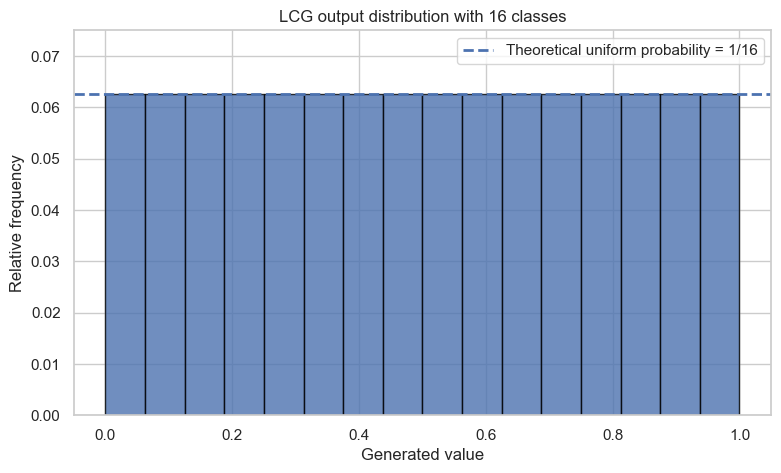

In [11]:
x_i = 3
a = 5
c = 1
M = 16
N = 10000
k = 16

data_1 = np.array(LCG(x_i,a,c,M,N))

visual_inspection_histogram(data_1,16)

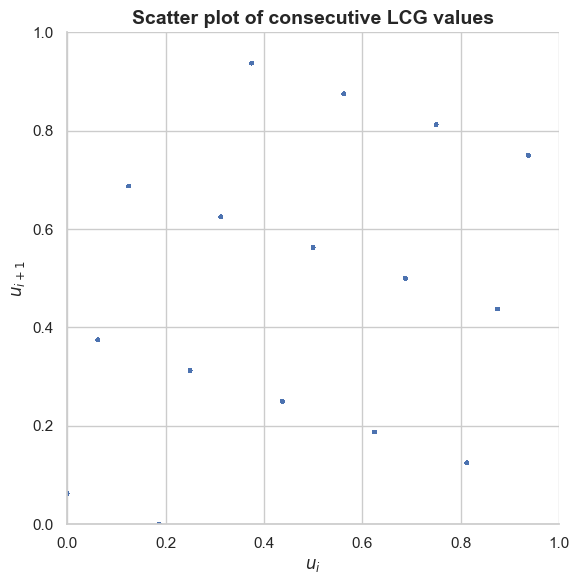

In [12]:
visual_inspection_scatter(data_1,'None')

In [75]:
def chi_square(data, group, significance=None):

    data = np.array(data)
    n = len(data)

    bins = np.linspace(0, 1, group + 1)

    observed, _ = np.histogram(data, bins=bins)

    expected = np.full(group, n / group)

    chi_stat = np.sum((observed-expected)**2/expected)

    return chi_stat

In [50]:
def KS(data):

    n = len(data)
    data_sorted = sorted(data) 

    d_plus = 0
    d_minus = 0
    
    for i, x in enumerate(data_sorted):
        d_plus  = max(d_plus,  (i + 1) / n - x)  
        d_minus = max(d_minus, x - i / n)         
    d = max(d_plus, d_minus)


    adjusted_test_statistic = (math.sqrt(n) + 0.12 + (0.11/math.sqrt(n))) * d

    return adjusted_test_statistic

In [15]:
def Wald_wolfowitz(data):

    median = sorted(data)[len(data)//2] #er den ikke altid 0,5 når man har normalizeret???

    signs = [1 if x > median else -1 for x in data]

    n_1 = signs.count(1) #number of samples above the median 
    n_2 = signs.count(-1) #number of sample below the median 

    T = 1 + sum(signs[i] != signs[i-1] for i in range(1, len(signs))) # number of runs are the number of sign flips + 1

    mean = 2*(n_1*n_2/(n_1+n_2)) + 1
    var = 2 * (n_1*n_2*(2*n_1*n_2-n_1-n_2))/((n_1+n_2)**2*(n_1 + n_2 - 1))



    z = (T - mean) / math.sqrt(var)
    p = 2 * (1 - 0.5 * (1 + math.erf(abs(z) / math.sqrt(2))))
    return T, z, p

In [16]:
def Knuth(data):
    n = len(data)
    
    lenghts = []
    run_length = 1
    for i in range(1,n):
        if data[i] > data[i-1]:
            run_length += 1
        else:
            lenghts.append(run_length)
            run_length = 1
    lenghts.append(run_length)

    R = [0]*6
    for L in lenghts:
        R[min(L, 6) - 1] += 1


    A = [
        [4529.4,  9044.9, 13568,  18091,  22615,  27892 ],
        [9044.9,  18097,  27139,  36187,  45234,  55789 ],
        [13568,   27139,  40721,  54281,  67852,  83685 ],
        [18091,   36187,  54281,  72414,  90470,  111580],
        [22615,   45234,  67852,  90470,  113262, 139476],
        [27892,   55789,  83685,  111580, 139476, 172860],
    ]
    B = [1/6, 5/24, 11/120, 19/720, 29/5040, 1/840]

    v = [R[i] - n*B[i] for i in range(6)]
    quad = sum(v[i]*A[i][j]*v[j] for i in range(6) for j in range(6))
    Z = quad / (n - 6)

    # 5. p-value from chi-square with 6 df (even df → closed form)
    h = Z / 2
    p = math.exp(-h) * (1 + h + h*h/2)

    return R, Z, p

In [17]:
def upside_down(data):
    n = len(data)

    up = [data[i] > data[i-1] for i in range(1,n)]

    X = 1+ sum(up[i] != up[i-1] for i in range(1, len(up)))

    mean = (2*n-1) / 3
    var = math.sqrt((16*n-29)/90)
    Z = (X - mean) / var

    return Z

In [18]:
def correlation_test(data, h):
    n = len(data)

    c_h = sum(data[i]*data[i+h] for i in range(n - h)) / (n - h)

    mean = 0.25
    var = 7/(144*n)

    Z = (c_h - mean) / math.sqrt(var)

    p = 2 * (1 - 0.5 * (1 + math.erf(abs(Z) / math.sqrt(2))))


    return c_h, Z, p

for h in [1, 2, 3]:
    c_h, Z, p = correlation_test(data_1, h)
    print(f"h={h}: c_h={c_h:.4f}, Z={Z:.3f}, p={p:.4f}")

h=1: c_h=0.2422, Z=-3.532, p=0.0004
h=2: c_h=0.2168, Z=-15.040, p=0.0000
h=3: c_h=0.1954, Z=-24.782, p=0.0000


### 1.2

In [19]:
def available_generator(N):
    numbers = []
    for i in range(N):
        numbers.append(np.random.random())
    return numbers

data_2 = np.array(available_generator(10000))

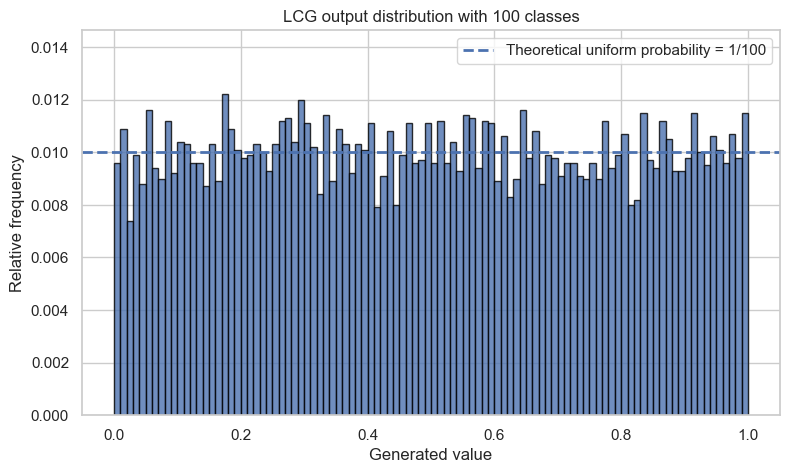

In [20]:
visual_inspection_histogram(data_2,100)

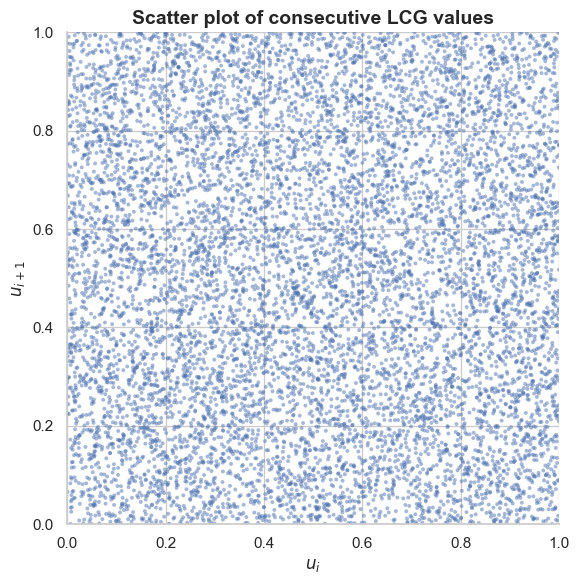

In [21]:
visual_inspection_scatter(data_2,'None')

In [22]:
chi_square(data_2,100)

np.float64(98.9)

In [23]:
KS(data_2)

np.float64(0.6584401322882233)

In [24]:
Wald_wolfowitz(data_2)

(4995, -0.12000200565070478, 0.9044815591619115)

### 1.3

## Exercise 2

### 2.1

[1, 2, 3, 2, 1, 1, 2, 1, 2, 4]


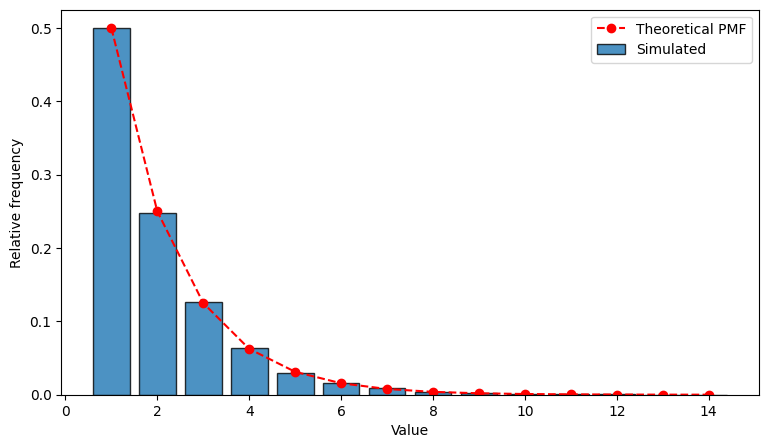

In [6]:
def visual_inspection_geometric(data, p):
    data = np.array(data)
    n = len(data)

    values = np.arange(1, data.max() + 1)
    proportions = np.array([np.sum(data == v) for v in values]) / n

    pmf = (1 - p) ** (values - 1) * p

    plt.figure(figsize=(9, 5))
    plt.bar(values, proportions, edgecolor="black", alpha=0.8, label="Simulated")
    plt.plot(values, pmf, "o--", color="red", label="Theoretical PMF")
    plt.xlabel("Value")
    plt.ylabel("Relative frequency")
    plt.legend()
    plt.show()


def geometric_sim(p,n):
    return [math.floor(math.log(random.random()) / math.log(1 - p)) + 1 for _ in range(n)]

sim_data = geometric_sim(0.5, 10000)
print(sim_data[:10])

visual_inspection_geometric(sim_data, 0.5)

### 2.2

In [7]:
prob_exec2 = [7/48, 5/48, 1/8, 1/16, 1/4, 5/16]

In [8]:
def direct_crude_method(probs, n):
    cumulative = 0.0
    cumulative_probabilities = []
    for p in probs: #built the intervals p
        cumulative += p
        cumulative_probabilities.append(cumulative) 
    

    sim_data = [0]*6
    
    for _ in range(n):
        u = random.random()
        
        for k, prob in enumerate(cumulative_probabilities): #increment count if u falls into the interval
            if u <= prob:
                sim_data[k] += 1
                break
    
    return sim_data

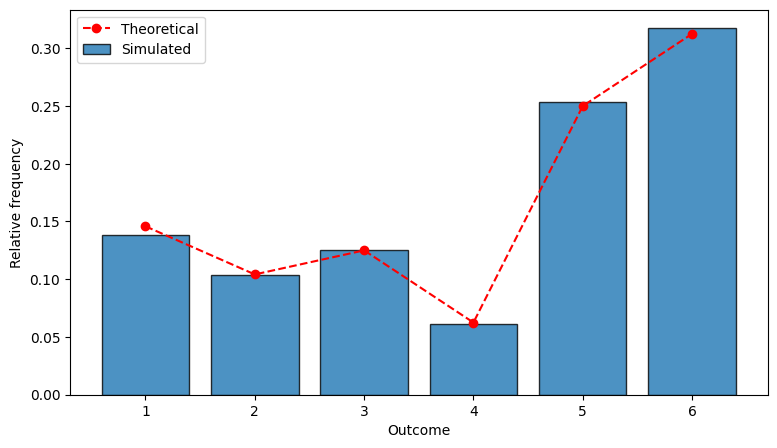

In [9]:
visual_inspection_discrete(direct_crude_method(prob_exec2,10000),6,prob_exec2)

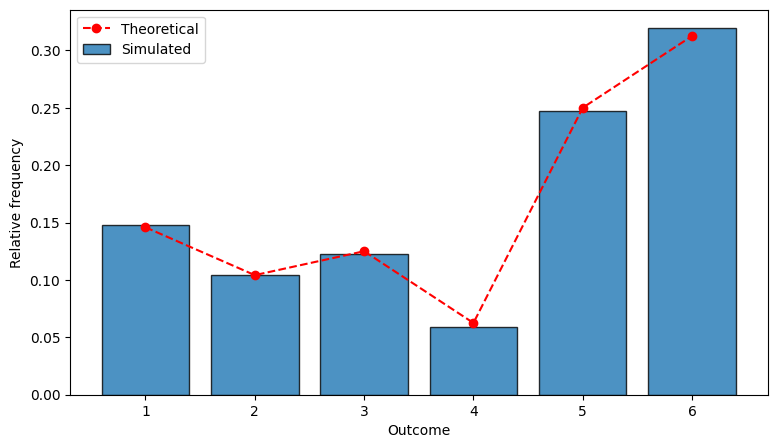

In [10]:
def simple_rejection(probs, n):
    k = len(probs)
    c = max(probs)

    sim_data = [0]*k

    for _ in range(n):
        while True:
            u1 = random.random()
            I = math.floor(k * u1)+1 
            u2 = random.random()

            if u2 <= (probs[I - 1] / c):
                sim_data[I-1] += 1
                break
    
    
    return sim_data
visual_inspection_discrete(simple_rejection(prob_exec2,10000), 6, prob_exec2)

In [20]:
def alias_setup(probs):
    k = len(probs)
    F = [k * x for x in probs]
    L = list(range(1,k+1))

    

    G = [i for i in range(1,k+1) if F[i - 1] >= 1]
    S = [i for i in range(1,k+1) if F[i - 1] < 1]


    while S:
        i = G[0]
        j = S[0]
        L[j - 1] = i 
        F[i - 1] = F[i - 1] - (1 - F[j - 1])
        S.remove(j)
        if F[i - 1] < 1:
            G.remove(i)
            S.append(i)

    return F, L    
  

def alias_sample(F, L, n):
    k = len(F)
    data = [0] * k  
    
    for _ in range(n):
        i = random.randint(1, k)
        u = random.random()
        
        if u < F[i - 1]:
            result = i
        else:
            result = L[i - 1]
        
        data[result - 1] += 1   
    
    return data      

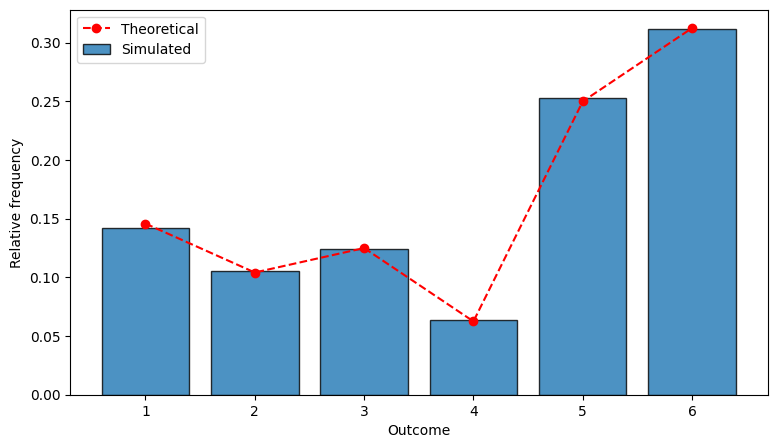

In [22]:
F, L = alias_setup(prob_exec2)
data = alias_sample(F, L, n=10000)

visual_inspection_discrete(data, k=len(prob_exec2), probs=prob_exec2)

## Exercise 3

### 3.1

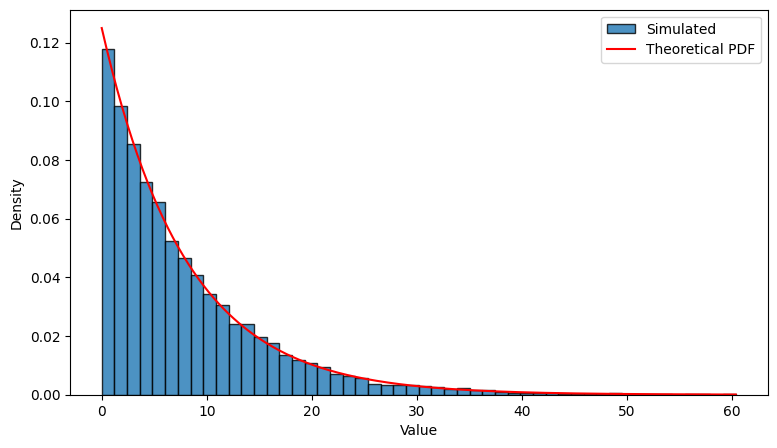

In [47]:
def exponential_sim(n,lam):
    return [(-math.log((random.random()))/lam) for _ in range(n)]

sim_data = exponential_sim(10000,(1/8))

def exponential_pdf(x):
    lam = 1/8
    return lam * math.exp(-lam*x)


visual_inspection_continuous(sim_data, exponential_pdf)

In [53]:
def normal_sim(u1,u2):
    z1 = math.sqrt(-2*math.log(u1)) * math.cos(2*math.pi*u2)
    z2 = math.sqrt(-2*math.log(u1)) * math.sin(2*math.pi*u2)

    return z1,z2

sim_normal = [normal_sim(random.random(), random.random()) for _ in range(100000)]

def normal_pdf(x):
    return (1/(1*math.sqrt(2*math.pi))*(math.exp(-1/2*(x-0/1)**2)))

#visual_inspection_continuous(sim_normal, normal_pdf,73)

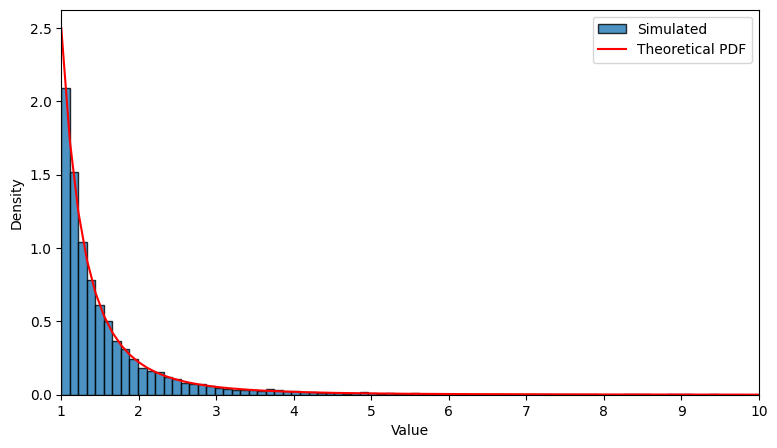

In [52]:
#note pareto 
def pareto_sim(n,k, beta=1):
    return [beta * random.random()**(-1/k) for _ in range(n)]

def pareto_pdf(x,k=2.5, beta=1):
    return (k * beta**k) / (x**(k+1))


k = 2.5
beta = 1
sim_data_pareto = pareto_sim(10000,k)

def visual_inspection_continuous_pareto_specific(data,pdf, bins=500):
    data = np.array(data).flatten()

    plt.figure(figsize=(9, 5))
    plt.hist(data, bins=bins, density=True, edgecolor="black", alpha=0.8, label="Simulated")

    x = np.linspace(min(data), max(data), 500)
    y = [pdf(xi) for xi in x]
    plt.plot(x, y, color="red", label="Theoretical PDF")
    plt.xlim(1, 10)

    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

visual_inspection_continuous_pareto_specific(sim_data_pareto, pareto_pdf)

In [54]:
def pareto_cdf(x, k=2.5, beta=1):
    return 1 - (beta / x) ** k

uniforms = [pareto_cdf(x) for x in sim_data_pareto]
KS(uniforms)

NameError: name 'KS' is not defined

### 3.2

In [58]:
beta = 1
k = 5
data = pareto_sim(100000,k=5,beta=1)

def analytical_pareto_mean(beta,k):
    return beta*(k/(k-1))

def analytica_pareto_variance(beta,k):
    return beta**2 * (k/((k-1)**2 * (k-2)))

def sample_mean(data):
    return sum(data) / len(data)

def sample_variance(data):
    m = sample_mean(data)
    return sum((x - m) ** 2 for x in data) / (len(data) - 1)

print({
    'sample mean':     sample_mean(data),
    'sample variance': sample_variance(data),
    'theo mean':       analytical_pareto_mean(beta, k),
    'theo variance':   analytica_pareto_variance(beta, k)
})

#if k < 1 the true mean is infinite. so k has to be above 1 
#variance exist only if k > 2 
# if k is 1 < k <= 2 the mean is finite, but variance infinite so it swings around wildly. 

{'sample mean': 1.2508709787853312, 'sample variance': 0.1050731315520412, 'theo mean': 1.25, 'theo variance': 0.10416666666666667}


### 3.3

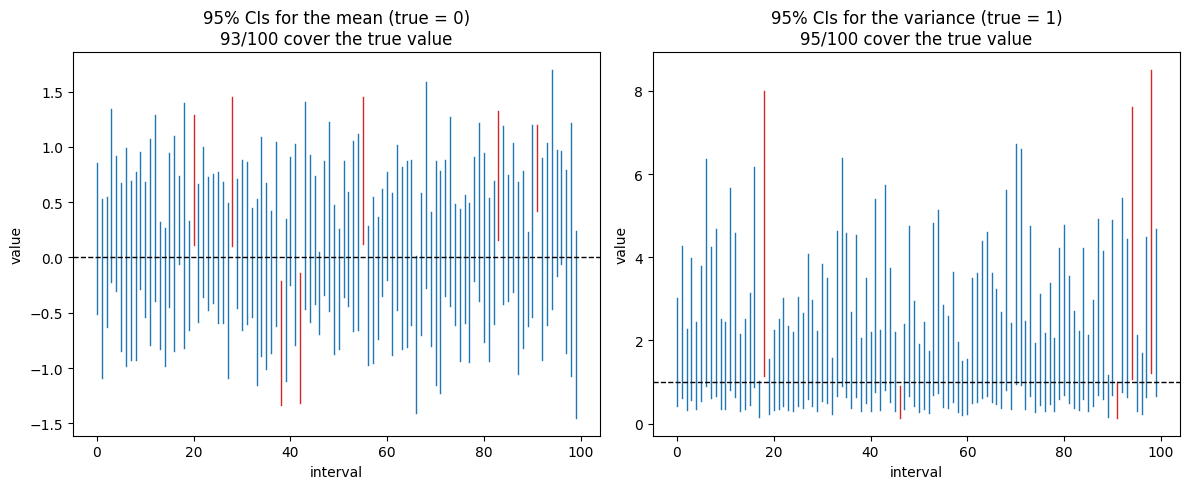

In [59]:
mu = 0
sigma = 1

t_crit     = 2.262  
chi2_lower = 2.700   
chi2_upper = 19.02 

mean_cis, var_cis = [], []
for _ in range(100): #builds 100 confidence intervals
    sample = [] 
    n = 10 #messy but there 10 generated
    for _ in range(n // 2): # generates sample. 
        z1, z2 = normal_sim(random.random(), random.random())
        sample.append(mu + sigma * z1)
        sample.append(mu + sigma * z2)

    sample_mean = sum(sample) / n
    sample_variance   = sum((x - sample_mean)**2 for x in sample) / (n - 1)
    sample_stdev    = math.sqrt(sample_variance)

    half = t_crit * sample_stdev / math.sqrt(n)
    mean_cis.append((sample_mean - half, sample_mean + half))
    var_cis.append(((n - 1) * sample_variance / chi2_upper, (n - 1) * sample_variance / chi2_lower))



def plot_cis(cis, true_value, title, ax):
    for i, (lo, hi) in enumerate(cis):
        covered = lo <= true_value <= hi
        ax.plot([i, i], [lo, hi], color="tab:blue" if covered else "tab:red", lw=1)
    ax.axhline(true_value, color="black", ls="--", lw=1)
    hits = sum(lo <= true_value <= hi for lo, hi in cis)
    ax.set_title(f"{title}\n{hits}/{len(cis)} cover the true value")
    ax.set_xlabel("interval"); ax.set_ylabel("value")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_cis(mean_cis, 0,       "95% CIs for the mean (true = 0)",     axes[0])
plot_cis(var_cis,  1, "95% CIs for the variance (true = 1)", axes[1])
plt.tight_layout()
plt.show()

### 3.4

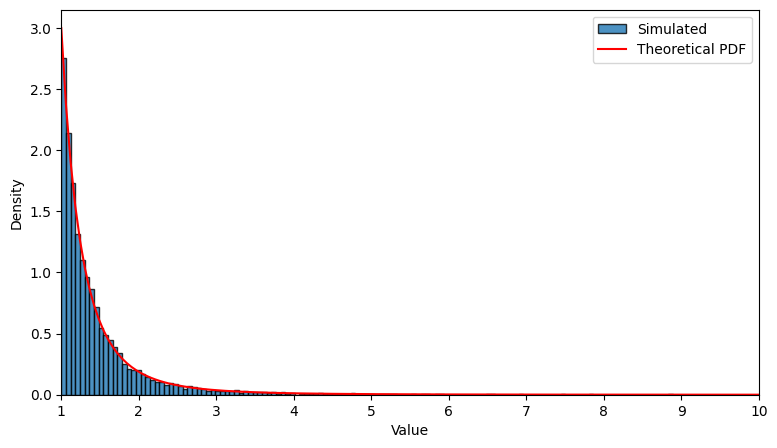

In [60]:
def pareto_by_composition(k,beta):
    Y = sum(-math.log(random.random()) for _ in range(k)) / beta #draws Y from k independet exponential distributions 
    X = -math.log(random.random())/ Y
    return X + beta

beta = 1
k = 3

composition_simulation_pareto = [pareto_by_composition(k,beta) for _ in range(10000)]


def pareto_pdf(x, k=3, beta=1):
    return k * beta**k / x**(k + 1)


visual_inspection_continuous_pareto_specific(composition_simulation_pareto,pareto_pdf,500)


## Exercise 4

### 4.1

In [207]:
def exponential_sim(lam):
    return -math.log((random.random()))/lam
    

In [208]:
def simulation_blocking_system(n_arrivals, m, inter_arrival_sampler, service_time_sampler):
    #state variables
    time = 0 
    arrivals = 0 
    blocked = 0 
    occupied = 0

    depature_times = []

    #randomly generated arrivals 
    next_arrival = inter_arrival_sampler()


    #initialize simulation
    while arrivals < n_arrivals:
        #keep track of the next depature
        next_depature = min(depature_times) if depature_times else float('inf')

        #next event is an arrival
        if next_arrival < next_depature:
            arrivals += 1
            time = next_arrival

            #if there is free capacity
            if occupied < m: 
                occupied += 1
                service_time = service_time_sampler()
                depature_times.append(time + service_time)
            
            #No free capacity 
            else:
                blocked += 1
            
            next_arrival = time + inter_arrival_sampler()

        
        #nex event is a depature
        else:
            occupied -= 1
            time = next_depature
            depature_times.remove(next_depature)

    
    estimate_proportion_blocked = blocked / arrivals

    return estimate_proportion_blocked



In [211]:
CI(simulation_blocking_system(
    10000,
    10,
    lambda: exponential_sim(1),
    lambda: exponential_sim(1/8)
),10000,1.96)

(0.118, [0.11167688082035455, 0.12432311917964543])

In [210]:
def CI(est_p, n,crit): #confidence interval
    SE = math.sqrt(est_p * (1-est_p) / n)
    CI = [est_p - (crit*SE), est_p + (crit*SE)]
    return est_p, CI

In [226]:
A = 8 
m = 10 
erlang = (A**m / math.factorial(m))/(sum(A**i / math.factorial(i) for i in range(m+1))) #Erlangs B-formula
erlang

0.12166106425295149

### 4.2

Erlang

In [227]:
def erlang_sim(k):
    return sum(-math.log(random.random()) for _ in range(k))/k 

In [228]:
simulation_blocking_system(
    10000,
    10,
    lambda: erlang_sim(8),
    lambda: exponential_sim(1/8),)

0.0638

Hyper exponential 

In [229]:
def hyperexp_sim( p, lam1, lam2):
    if random.random() < p:
        return exponential_sim(lam1)
    else:
        return exponential_sim(lam2)
    

In [230]:
simulation_blocking_system(
    10000,
    10,
    lambda: hyperexp_sim(0.8,0.8333,5.0),
    lambda: exponential_sim(1/8),)

0.1314

### 4.3

constant time 

In [231]:
def constant_time(a):
    a = 8
    return 8

In [232]:
CI(simulation_blocking_system(
    10000,
    10,
    lambda: exponential_sim(1),
    lambda: constant_time(8)
    
),10000,1.96)

[0.11802903840530636, 0.13097096159469362]

pareto simulation 

In [233]:
def pareto_sim(k):
    beta = 8 * (k - 1) / k
    return beta * random.random()**(-1/k)

In [234]:
CI(simulation_blocking_system(
    10000,
    10,
    lambda: exponential_sim(1),
    lambda: pareto_sim(1.05)
    
),10000,1.96)

[6.184025744028005e-05, 0.0009381597425597199]

In [235]:
CI(simulation_blocking_system(
    10000,
    10,
    lambda: exponential_sim(1),
    lambda: pareto_sim(2.05)
    
),10000,1.96)

[0.10055136124484194, 0.11264863875515806]

erlang

In [236]:
CI(simulation_blocking_system(
    10000,
    10,
    lambda: exponential_sim(1),
    lambda: erlang_sim(59)
),10000,1.96)

[0.0, 0.0]

### 4.4

See other 4.1,4.2,4.3

CI for simulating the system with exponential inter-arrival distribution places the CI around the value found with the analytical solution. The exponential distributions variance is not high enough to significantly skew the estimate of the proportion. 

This is another case when using the Erlang distribution with n = 8 meaning the sum of 8 different exponential distributions. Consequently the arrivals are mor regular, thus blocking decreases as seen in the CI. 

The hyperexponential combines an exponential with rate parameter 5.0 happening with p=0.2 and another exponentiual rate = 0.833 happening withp=0.8. Thus 1/5 times the arrivals are more regular and frequent and the variation is low. Conversely 4/5 times the arrivals have much higher variance contributing to higher blocking. 

The next point is that varying the service time does not affect blocking. Having constant service time yields the same proportion of blocking as exponential service time. The mean of service time using the exponential is 8, so in this model most customers are serviced for 8 time units, or less. The difference from constant time, is its heavy tail that entails improbable but possible higher service times. Whatsoever the constant time vs the exponential with mean 8 does not yield much different results, In general the blocking is significantly more affected by the load given my the arrival distribution. Service time does not affect blocking as the customers who are blocked changes with higher or lower arrival. 
The pareto distribution for service time with k= 2.05 supports that. Here the blocking is also insensitive to the obscurede service time.However the pareto k = 1.05 has a much lower blocking. The reason is the fat tails which draws the service time down a lot. However the variance is infinite at k < 2... estimating the mean of the service time requires variance to be finite, and this pareto violates that.





## Exercise 5

### 5.1 - 5.4

In [23]:
def crude_monte_carlo_estimator_exponential(n):
    sim_data = [math.exp(random.random()) for _ in range(n)]

    point_estimate = sum(sim_data) / len(sim_data)
    sample_variance = sum((x - point_estimate)**2 for x in sim_data) / (len(sim_data) - 1)
    estimator_variance = sample_variance / len(sim_data)
    SE = math.sqrt(estimator_variance)

    crit = 1.96
    CI = [point_estimate - (crit * SE), point_estimate + (crit * SE)]
    return point_estimate, CI

crude_monte_carlo_estimator_exponential(100)

(1.7751262349510424, [1.6796376803090476, 1.8706147895930372])

In [ ]:
def anti_thetic_exponential(n):
    sim_data = []
    for _ in range(n):
        u = random.random()
        sim_data.append((math.exp(u) + math.exp(1-u))/2)  

    point_estimate = sum(sim_data) / len(sim_data)
    sample_variance = sum((x - point_estimate)**2 for x in sim_data) / (len(sim_data) - 1)
    estimator_variance = sample_variance / len(sim_data)
    SE = math.sqrt(estimator_variance)

    crit = 1.96
    CI = [point_estimate - (crit * SE), point_estimate + (crit * SE)]
    
    return  point_estimate, CI

anti_thetic_exponential(100)


100


(1.7151266571695007, [1.7036594258462419, 1.7265938884927596])

In [25]:
def control_variate_exponential(n):
    uni = [random.random() for _ in range(n)]
    X = [math.exp(u) for u in uni]
    Y = uni 

    X_expec = sum(X) / n
    Y_expec = sum(Y) / n
    cov = sum((X[i] - X_expec) * (Y[i] - Y_expec) for i in range(n)) / (n - 1)
    Y_var = sum((y - Y_expec)**2 for y in Y) / (n - 1)
    c = (cov / Y_var)

    sim_data = [X[i] - c * (Y[i] - 0.5) for i in range(n)]


    point_estimate = sum(sim_data) / len(sim_data)
    sample_variance = sum((x - point_estimate)**2 for x in sim_data) / (len(sim_data) - 1)
    estimator_variance = sample_variance / len(sim_data)
    SE = math.sqrt(estimator_variance)

    crit = 1.96
    CI = [point_estimate - (crit * SE), point_estimate + (crit * SE)]

    return point_estimate, CI

control_variate_exponential(100)

(1.7161285458429314, [1.7036962855496578, 1.728560806136205])

In [26]:
def stratified_sampling(n_in_strata, stratas):
    intervals = []
    var = 0
    for j in range(stratas):
        sim_data = []
        for _ in range(n_in_strata):
            u = random.random()
            x = (j + u) / stratas
            sim_data.append(math.exp(x))
        mean_jth_strata = sum(sim_data) / len(sim_data)
        var_jth_strata = sum((y - mean_jth_strata)**2 for y in sim_data) / (len(sim_data) - 1)
        intervals.append(mean_jth_strata / stratas)
        var += var_jth_strata / (stratas * stratas * n_in_strata)

    point_estimate = sum(intervals)
    estimator_variance = var  
    SE = math.sqrt(estimator_variance)    
    crit = 1.96

    CI = [point_estimate - (crit * SE), point_estimate + (crit * SE)]

    return point_estimate, CI


stratified_sampling(10,10)

(1.7200139318660035, [1.7095310606830119, 1.7304968030489951])

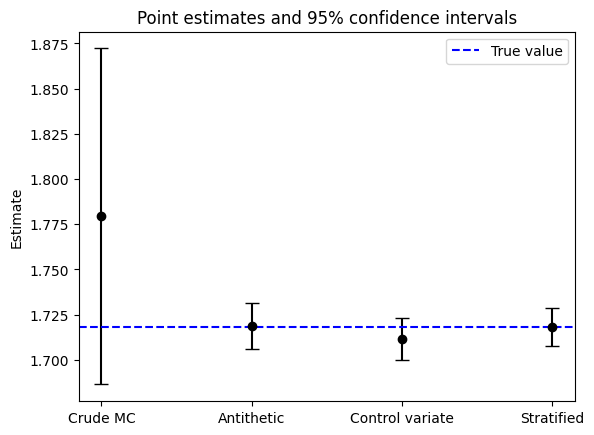

In [36]:
#seed
random.seed(345)

true_value = math.e - 1

methods = [
    ("Crude MC", crude_monte_carlo_estimator_exponential, (100,)),
    ("Antithetic", anti_thetic_exponential, (100,)),
    ("Control variate", control_variate_exponential, (100,)),
    ("Stratified", stratified_sampling, (10, 10))
]

names = []
estimates = []
lower = []
upper = []

for name, func, args in methods:
    result = func(*args)      
    estimate = result[0]      
    CI = result[-1]           

    names.append(name)
    estimates.append(estimate)
    lower.append(CI[0])
    upper.append(CI[1])

errors_lower = [estimates[i] - lower[i] for i in range(len(names))]
errors_upper = [upper[i] - estimates[i] for i in range(len(names))]

plt.errorbar(
    names,
    estimates,
    yerr=[errors_lower, errors_upper],
    fmt="o",
    capsize=5,
    color='black'
)

plt.axhline(true_value, linestyle="--", label="True value",color='blue')
plt.ylabel("Estimate")
plt.title("Point estimates and 95% confidence intervals")
plt.legend()

#plt.savefig("EX5-1-2-3-4_CI.pdf", bbox_inches="tight")

plt.show()

In [38]:


random.seed(345)

methods = [
    ("Crude MC", crude_monte_carlo_estimator_exponential, (100,), "n = 100"),
    ("Antithetic", anti_thetic_exponential, (100,), "n = 100 pairs"),
    ("Control variate", control_variate_exponential, (100,), "n = 100"),
    ("Stratified", stratified_sampling, (10, 10), "10 strata, 10 samples each")
]

rows = []

for name, func, args, setup in methods:
    point_estimate, CI = func(*args)
    lower, upper = CI
    rows.append([
        name,
        setup,
        point_estimate,
        lower,
        upper,
        upper - lower
    ])

df = pd.DataFrame(
    rows,
    columns=["Method", "Setup", "Point estimate", "CI lower", "CI upper", "CI width"]
)

df.to_latex(
    "EX5-1-2-3-4_variance_and_CI.tex",
    index=False,
    float_format="%.4f"
)


### 5.5

In [203]:
# def exponential_sim_variat_control(n,lam):
#     return [(-math.log((random.random()))/lam) for _ in range(n)]
def exponential_sim(lam):
    return -math.log((random.random()))/lam
    
def simulation_blocking_system_control_variate(n_arrivals, m, inter_arrival_sampler, service_time_sampler):
    #state variables
    time = 0 
    arrivals = 0 
    blocked = 0 
    occupied = 0

    depature_times = []

    service_timess = []

    #randomly generated arrivals 
    next_arrival = inter_arrival_sampler()


    #initialize simulation
    while arrivals < n_arrivals:
        #keep track of the next depature
        next_depature = min(depature_times) if depature_times else float('inf')

        #next event is an arrival
        if next_arrival < next_depature:
            arrivals += 1
            time = next_arrival

            #if there is free capacity
            if occupied < m: 
                occupied += 1
                service_time = service_time_sampler()
                service_timess.append(service_time)
                depature_times.append(time + service_time)
            
            #No free capacity 
            else:
                blocked += 1
            
            next_arrival = time + inter_arrival_sampler()

        
        #nex event is a depature
        else:
            occupied -= 1
            time = next_depature
            depature_times.remove(next_depature)

    
    estimate_proportion_blocked = blocked / arrivals
    mean_service_time = sum(service_timess) / len(service_timess)

    return estimate_proportion_blocked, mean_service_time

In [204]:
def control_variate_exec4(n):
    X = []
    Y = []

    for _ in range(n):
        pb, mst = simulation_blocking_system_control_variate(10000,10,lambda:exponential_sim(1),lambda: exponential_sim(1/8))
        X.append(pb)
        Y.append(mst)

    X_expec = sum(X) / n
    Y_expec = sum(Y) / n
    cov = sum((X[i] - X_expec) * (Y[i] - Y_expec) for i in range(n)) / (n - 1)
    Y_var = sum((y - Y_expec)**2 for y in Y) / (n - 1)
    c = (cov / Y_var)

    sim_data = [X[i] - c * (Y[i] - 8) for i in range(n)]


    proportion_estimate = sum(sim_data) / len(sim_data)
    p_variance = sum((x - proportion_estimate)**2 for x in sim_data) / (len(sim_data) - 1)
    estimator_variance = p_variance / len(sim_data)
    SE = math.sqrt(estimator_variance)

    crit = 1.96
    CI = [proportion_estimate - (crit * SE), proportion_estimate + (crit * SE)]
    
    return proportion_estimate, CI

 

control_variate_exec4(100)

(0.12150213487142145, [0.12054938410242597, 0.12245488564041693])

In [205]:
def crude_sim_100_runs(n):
    sim_data = []

    for _ in range(n):
        p_block = simulation_blocking_system(
            10000,
            10,
            lambda: exponential_sim(1),
            lambda: exponential_sim(1/8))
        sim_data.append(p_block)
    
    
    proportion_estimate = sum(sim_data) / len(sim_data)
    p_variance = sum((x - proportion_estimate)**2 for x in sim_data) / (len(sim_data) - 1)
    estimator_variance = p_variance / len(sim_data)
    SE = math.sqrt(estimator_variance)

    crit = 1.96
    CI = [proportion_estimate - (crit * SE), proportion_estimate + (crit * SE)]
    
    return proportion_estimate, CI
    

In [212]:
crude_sim_100_runs(100)

(0.12105999999999999, [0.11989963879953025, 0.12222036120046972])

In [213]:


random.seed(12345)

methods = [
    ("Crude simulation", crude_sim_100_runs, (1000,), "n = 1000 runs"),
    ("Control variate adjusted", control_variate_exec4, (1000,), "n = 1000 runs")
    
]

rows = []

for name, func, args, setup in methods:
    proportion_estimate, CI = func(*args)
    lower, upper = CI
    rows.append([
        name,
        setup,
        proportion_estimate,
        lower,
        upper,
        upper - lower
    ])

df = pd.DataFrame(
    rows,
    columns=["Method", "Setup", "Proportion estimate", "CI lower", "CI upper", "CI width"]
)

df.to_latex(
    "EX5-5_CV_comparison.tex",
    index=False,
    float_format="%.4f"
)

### 5.6

wuhhhuuuuuuuuuu

### 5.7

In [197]:
def normal_draw(u1,u2):
    #z1 = math.sqrt(-2*math.log(u1)) * math.cos(2*math.pi*u2)
    z2 = math.sqrt(-2*math.log(u1)) * math.sin(2*math.pi*u2)
   
    return z2

In [198]:
def crude(n,a):
    sum = 0
    for _ in range(n):
        x = normal_draw(random.random(),random.random())
        if x > a: 
            decision = 1
        else: 
            decision = 0
        sum+= decision
        
    return (sum/n)

crude(100,1)  


0.14

In [199]:
def fg(x,a,std):
    return (1 / math.sqrt(2* math.pi * std**2)) * math.exp(-1/2 * (((x-a)/std)**2))

In [200]:
def importance_sampling_normal(a,std,n):
    s = 0 
    for _ in range(n):
        x = normal_draw(random.random(),random.random()) * std + a 
        if x > a:
            decision = (fg(x,0,1)/fg(x,a,std))
        else:
            decision = 0 
        s += decision
    
    return s/n

importance_sampling_normal(1,1,100)

0.17795269386744106

In [ ]:
random.seed(522)

a_values = [2, 4]
n_values = [100, 1000, 10000]
std = 1

rows = []

for a in a_values:
    true_value = 0.5 * math.erfc(a / math.sqrt(2))

    for n in n_values:
        crude_est = crude(n, a)
        is_est = importance_sampling_normal(a, std, n)

        rows.append([
            a,
            n,
            true_value,
            crude_est,
            is_est,
            abs(crude_est - true_value),
            abs(is_est - true_value)
        ])

df = pd.DataFrame(
    rows,
    columns=[
        "a",
        "n",
        "True value",
        "Crude MC",
        "Importance sampling",
        "Crude abs. error",
        "IS abs. error"
    ]
)



### 5.8

In [ ]:
def exponential_draw(lam):
    return -math.log(random.random())/lam

def h(x):
    return math.exp(x)

def g_proposal(x,lam):
    return lam*math.exp(-lam*x)


def importance_sampling_exponential(n,lam):
    sum = 0 
    
    for _ in range(n):
        x = exponential_draw(lam)
        if x <= 1:
            decision = h(x) / g_proposal(x,lam)
        else:
            decision = 0 
        sum += decision
    return sum / n

        
importance_sampling_exponential(10000,3)
#considering e-1 = 1.72

1.718524180857511

In [191]:
random.seed(8634)

lambdas = []
variances = []

for i in range(1,30):
    lam = i /10 

    est = []

    for _ in range(1000):
        estimate = importance_sampling_exponential(10000,lam)
        est.append(estimate)
    
    average_estimate = sum(est) / len(est)

    var = sum((x - average_estimate)**2 for x in est) / (len(est)-1)

    lambdas.append(lam)
    variances.append(var)


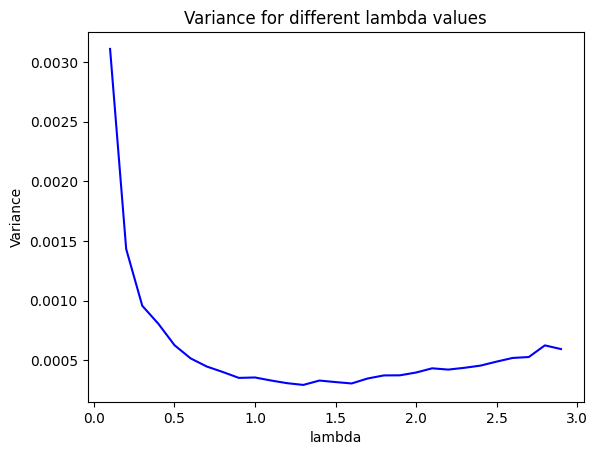

In [ ]:
plt.plot(lambdas, variances, color='blue')
plt.xlabel("lambda")
plt.ylabel("Variance")
plt.title("Variance for different lambda values")

#plt.savefig("EX5-8_lambda_values.pdf", bbox_inches="tight")

plt.show()

In [193]:
best_index = variances.index(min(variances))

print("Best lambda:", lambdas[best_index])
print("Lowest variance:", variances[best_index])

Best lambda: 1.3
Lowest variance: 0.000294271349190475


### 5.9

## Exercise 6

### 6.1

In [5]:
def metropolis_hasting(A,m,N):
    current_state = 2
    samples = []
    def g(x):
        if x < 0 or x > m:
            return 0 
        else:
            return A**x / math.factorial(x)

    for _ in range(N):
        random_draw = random.choice([-1,1])
        proposal = current_state + random_draw
        acceptance_ratio = min(1, g(proposal)/g(current_state))

        if g(proposal) > g(current_state) or acceptance_ratio > random.random():
            current_state = proposal
            samples.append(current_state)
        else:
            current_state = current_state
            samples.append(current_state)
    
    return samples


In [6]:
def empirical(samples, m):
    counts = [0] * (m+1)
    for s in samples:
        counts[s] += 1
    return [c / len(samples) for c in counts]

In [7]:
def true_distribution(A, m):
    weights = [A**i / math.factorial(i) for i in range(m + 1)]
    total = sum(weights)
    return [w / total for w in weights]

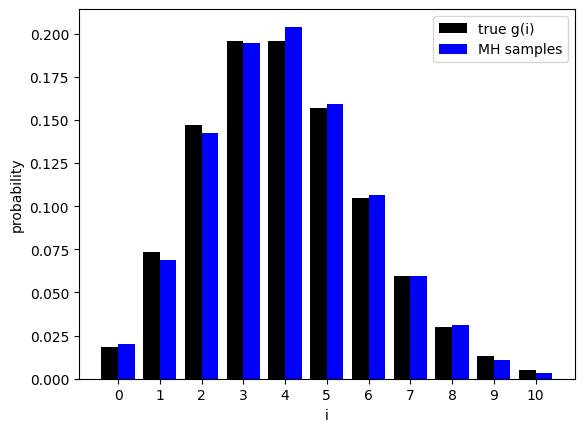

In [ ]:
random.seed(4522645)

true = true_distribution(4,10)
samples = empirical(metropolis_hasting(4,10,10000),10)

x = list(range(10 + 1))
plt.bar([i - 0.2 for i in x], true, width=0.4, label="true g(i)",color='black')
plt.bar([i + 0.2 for i in x], samples,  width=0.4, label="MH samples",color='blue')
plt.xlabel("i"); plt.ylabel("probability"); plt.xticks(x); plt.legend()
#plt.savefig("EX6-1_sample_vs_true.pdf", bbox_inches="tight")
plt.show()

obs = np.bincount(samples, minlength=11)
expected = len(samples) * np.array(true)
test_statistic, p_value = chisquare(f_obs=obs,f_exp=expected)

df = pd.DataFrame({
    "test statistic": [test_statistic],
    "p-value": [p_value]
})

# df.to_latex(
#     "EX6-1_chi_square.tex",
#     index=False,
#     float_format="%.4f"
# )

### 6.2

#### expected frequencies for chi-square and heatmap function

In [ ]:
m = 10
states = []

for i in range(m+1):
    for j in range(m+1):
        if i + j <= m: 
            states.append((i,j))

def true_joint_distribution(A1,A2,m):
    states = []

    for i in range(m+1):
        for j in range(m+1):
            if i + j <= m: 
                states.append((i,j))
            
    weights = []

    for i,j in states: 
        weight = (A1**i / math.factorial(i)) * (A2**j / math.factorial(j))
        weights.append(weight)
    
    total = sum(weights)
    probabilities = [w / total for w in weights]

    return states, probabilities



def chi_square_result(name, samples, states, true_probs, burn_in=0):
    samples = samples[burn_in:]
    counts = Counter(samples)

    obs = []
    for state in states:
        obs.append(counts[state])

    obs = np.array(obs)
    expected = len(samples) * np.array(true_probs)
    expected = expected * obs.sum() / expected.sum()

    result = chisquare(f_obs=obs, f_exp=expected)

    return {
        "Sampler": name,
        "Chi-square statistic": result.statistic,
        "p-value": result.pvalue
    }

In [768]:
def plot_heatmap(samples,m, title,save_id):
    matrix = np.full((m+1,m+1), np.nan)
    
    

    for i in range(m+1):
        for j in range(m+1):
            if i + j <= m:
                matrix[j,i] = 0

    for i,j in samples:
        if 0 <= i <= m and 0 <= j <= m and i+j <= m: 
            matrix[j,i] += 1

    matrix = matrix / len(samples)

    plt.figure(figsize=(7, 5))
    plt.imshow(matrix, origin="lower", aspect="equal")
    plt.colorbar(label="Empirical probability")
    plt.xlabel("i")
    plt.ylabel("j")
    plt.title(title)
    plt.savefig(save_id, bbox_inches="tight")
    plt.show()

#### 6.2.1

10000
Power_divergenceResult(statistic=198.3326692917287, pvalue=2.0668807928937718e-15)


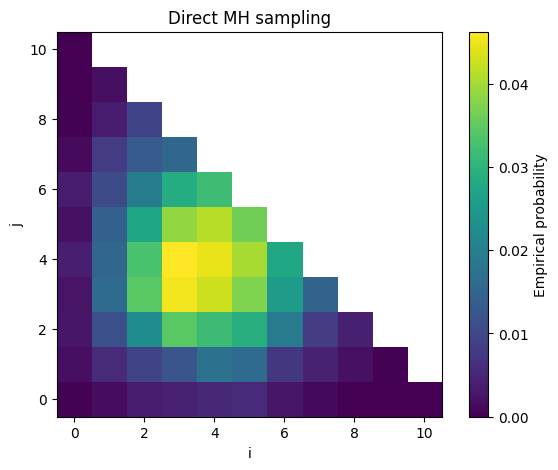

In [769]:
random.seed(1234543)

def metropolis_hasting_joint(A1,A2,m,N):
    i_state,j_state  = 2,2
    samples = []
    def g(i,j):
        if i < 0 or j < 0 or i + j > m:
            return 0
        else:
            return A1**i / math.factorial(i) * A2**j / math.factorial(j)
    
    for _ in range(N):
        i_draw, j_draw = random.choice([(1,0), (-1,0), (0,1), (0,-1)])

        proposal_i = i_state + i_draw
        proposal_j = j_state + j_draw

        acceptance_ratio = min(1,g(proposal_i,proposal_j) / g(i_state,j_state))

        if acceptance_ratio > random.random():
            i_state = proposal_i
            j_state = proposal_j
        
        samples.append((i_state, j_state))
    
    return samples

states, true_probs = true_joint_distribution(4,4,10)
samples = metropolis_hasting_joint(4,4,10,10000)
print(len(samples))
counts = Counter(samples)
obs = []
for state in states:
    obs.append(counts[state])
expected = len(samples) * np.array(true_probs)
print(chisquare(f_obs=obs,f_exp=expected))


plot_heatmap(samples[1000:], 10,"Direct MH sampling","EX6-2_MH_direct.pdf")

#### 6.2.2

Power_divergenceResult(statistic=126.9454640970807, pvalue=6.849855538134847e-06)


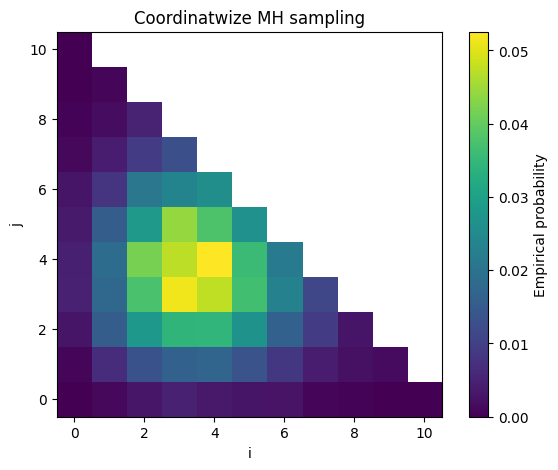

In [770]:
random.seed(1234543)


def metropolis_hasting_coordinatwize(A1,A2,m,N):
    i_state,j_state = 2,2
    samples = []
    def g(i,j):
        if i < 0 or j < 0 or i + j > m:
            return 0
        else:
            return A1**i / math.factorial(i) * A2**j / math.factorial(j)
    
    for _ in range(N):
        
        i_random_draw = random.choice([-1,1])
        i_proposal = i_state + i_random_draw
        acceptance_ratio = min(1, g(i_proposal,j_state)/g(i_state,j_state))

        if g(i_proposal,j_state) > g(i_state,j_state) or acceptance_ratio > random.random():
            i_state = i_proposal
        
        j_random_draw = random.choice([-1,1])
        j_proposal = j_state + j_random_draw
        acceptance_ratio = min(1, g(i_state,j_proposal)/g(i_state,j_state))

        if g(i_state,j_proposal) > g(i_state,j_state) or acceptance_ratio > random.random():
            j_state = j_proposal
        
        samples.append((i_state, j_state))
    
    return samples

states, true_probs = true_joint_distribution(4,4,10)
samples = metropolis_hasting_coordinatwize(4,4,10,10000)
counts = Counter(samples)
obs = []
for state in states:
    obs.append(counts[state])
expected = len(samples) * np.array(true_probs)
print(chisquare(f_obs=obs,f_exp=expected))

plot_heatmap(samples[1000:], 10, "Coordinatwize MH sampling","EX6-2_MH_coordinatwise.pdf")

#### 6.2.3

Power_divergenceResult(statistic=73.84277411612373, pvalue=0.21161700103500497)


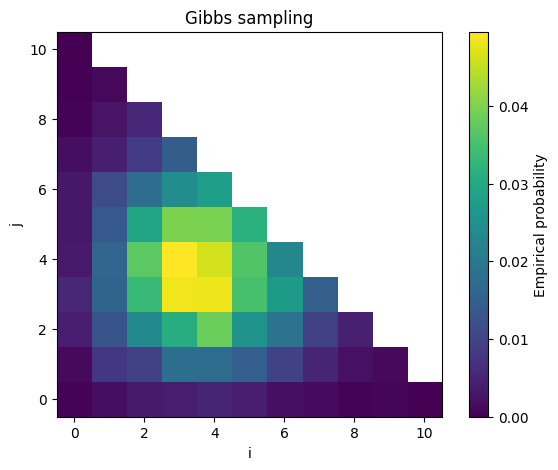

In [771]:
random.seed(1234543)


def gibbs(A1,A2,m,N):

    def conditional_sampler(A,K):
        w = [A**k / math.factorial(k) for k in range(K+1)]
        total = sum(w)
        u = random.random()
        running = 0 
        for k in range(K + 1):
            running += w[k] / total
            if running > u: 
                return k 
        return k 

    i, j = 1, 1
    sample_list = []

    for _ in range(N):
        i = conditional_sampler(A1, m-j)
        j = conditional_sampler(A2, m-i)

        sample_list.append((i,j))


    return sample_list


states, true_probs = true_joint_distribution(4,4,10)
samples = gibbs(4,4,10,10000)
counts = Counter(samples)
obs = []
for state in states:
    obs.append(counts[state])
expected = len(samples) * np.array(true_probs)
print(chisquare(f_obs=obs,f_exp=expected))

plot_heatmap(samples[1000:], 10, "Gibbs sampling","EX6-2_gibbs_sampling.pdf")

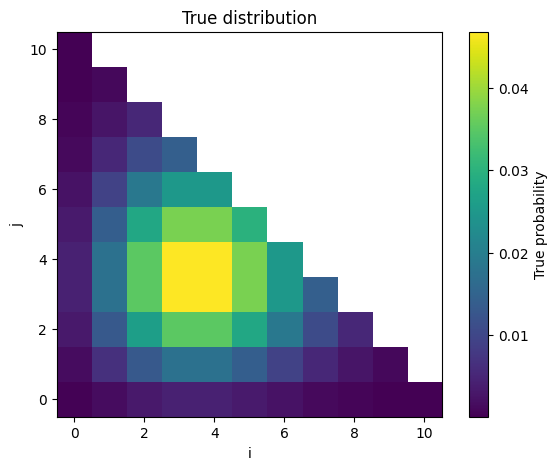

In [ ]:
#true heatmap
def plot_true_heatmap(A1, A2, m):
    matrix = np.full((m + 1, m + 1), np.nan)

    total = 0
    for i in range(m + 1):
        for j in range(m + 1):
            if i + j <= m:
                value = A1**i / math.factorial(i) * A2**j / math.factorial(j)
                matrix[j, i] = value
                total += value

    matrix = matrix / total

    plt.figure(figsize=(7, 5))
    plt.imshow(matrix, origin="lower", aspect="equal")
    plt.colorbar(label="True probability")
    plt.xlabel("i")
    plt.ylabel("j")
    plt.title("True distribution")
    #plt.savefig("EX6-2_true distribution.pdf", bbox_inches="tight")
    plt.show()

plot_true_heatmap(4,4,10)


In [772]:
random.seed(1234543)


A1, A2, m, N = 4, 4, 10, 10000
burn_in = 1000

A1, A2 = 4,4
m = 10 
N = 10000

states, true_probs = true_joint_distribution(A1, A2, m)

samples_direct = metropolis_hasting_joint(A1, A2, m, N)
samples_coord = metropolis_hasting_coordinatwize(A1, A2, m, N)
samples_gibbs = gibbs(A1, A2, m, N)

df = pd.DataFrame([
    chi_square_result("Direct MH", samples_direct, states, true_probs, burn_in),
    chi_square_result("Coordinatewise MH", samples_coord, states, true_probs, burn_in),
    chi_square_result("Gibbs", samples_gibbs, states, true_probs, burn_in)
])

# df.to_latex(
#     "EX6-2_chi_square.tex",
#     index=False,
#     float_format="%.4f"
# )

df

,Sampler,Chi-square statistic,p-value
0,Direct MH,213.057776,1.214271e-17
1,Coordinatewise MH,106.184844,9.586608e-04
2,Gibbs,85.522996,4.490919e-02


### 6.3

#### 6.3.1

In [ ]:
random.seed(1207)
def normal_sim_z1(u1,u2):
    z1 = math.sqrt(-2*math.log(u1)) * math.cos(2*math.pi*u2)
    return z1

def normal_sim_both_z1z2(u1,u2):
    z1 = math.sqrt(-2*math.log(u1)) * math.cos(2*math.pi*u2)
    z2 = math.sqrt(-2*math.log(u1)) * math.sin(2*math.pi*u2)
    return z1,z2

z1, z2 = normal_sim(random.random(), random.random())


#force correlation 
xi = z1
gamma = p * z1 + math.sqrt(1-p**2) * z2
theta = math.exp(xi)
psi = math.exp(gamma)

#draw 10 X
def normal_sim_z1(u1,u2):
        z1 = math.sqrt(-2*math.log(u1)) * math.cos(2*math.pi*u2)
        return z1

X = [normal_sim_z1(random.random(), random.random()) * math.sqrt(psi) + theta for _ in range(10)]

scaling_C = 4.0

def posterior(theta,psi):
    def joint_likelihood_helper(x,theta,psi):
        return scaling_C * ((1/math.sqrt(2*math.pi*psi)) * math.exp(- ((x-theta)**2/(2*psi))))
    
    likelihood = math.prod([joint_likelihood_helper(x,theta,psi) for x in X ])

    prior = (1/(2*math.pi*theta*psi*math.sqrt(3))) * math.exp(-2/3 * (math.log(theta)**2 - math.log(theta) * math.log(psi) + math.log(psi)**2))

    posterior = likelihood * prior

    return posterior

# posterior(theta,psi)
# # print(theta)
# # print(psi)

2.246292254124358
1.7009014682234262


In [738]:
random.seed(1207)
def bayes_metropolis_hastings(X, number_of_samples,sd):
    mean_X = sum(X)/len(X)
    var_X  = sum((x - mean_X)**2 for x in X)/len(X)
    theta_current = mean_X
    psi_current   = var_X
    p_current = posterior(theta_current, psi_current)

    samples = []
    accepted = 0 

    for _ in range(number_of_samples):
        theta_proposal = math.exp(math.log(theta_current) + random.normalvariate(0, sd))
        psi_proposal = math.exp(math.log(psi_current) + random.normalvariate(0, sd))
        p_proposal = posterior(theta_proposal, psi_proposal)

        if random.random() < (p_proposal / p_current) * (theta_proposal * psi_proposal) / (theta_current * psi_current):
            accepted += 1 
            theta_current = theta_proposal
            psi_current = psi_proposal
            p_current = p_proposal
        samples.append((theta_current, psi_current))
    
    acceptance_rate = accepted / number_of_samples

    return acceptance_rate, samples


In [739]:
random.seed(1207)

rate, samples = bayes_metropolis_hastings(X, 10000,0.5)
burn = 1000
post_theta = [s[0] for s in samples[burn:]]
post_psi   = [s[1] for s in samples[burn:]]


df = pd.DataFrame({
    "parameter": ["theta", "psi"],
    "estimate": [sum(post_theta) / len(post_theta),sum(post_psi) / len(post_psi)],
    "true value": [theta,psi]
})

# df.to_latex(
#     "EX6-3_n=1000.tex",
#     index=False,
#     float_format="%.4f"
# )

df

,parameter,estimate,true value
0,theta,2.007323,2.246292
1,psi,1.875738,1.700901


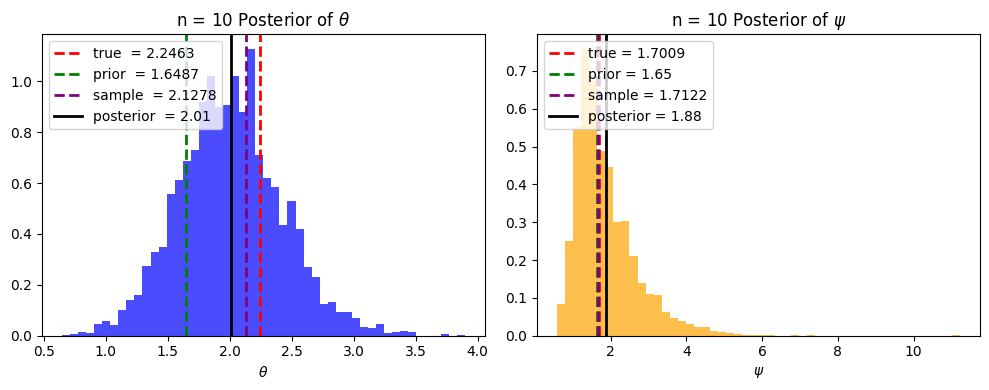

In [ ]:
random.seed(1207)

true_theta, true_psi = round(theta,4), round(psi,4)
mean_theta = sum(post_theta)/len(post_theta)
mean_psi   = sum(post_psi)/len(post_psi)
prior_mean_psi = 1.65
prior_mean_theta = round(math.exp(0.5),4)
sample_mean = round(sum(X) / len(X),4)
sample_variance = round(sum([(x - sample_mean)**2 for x in X]) / (len(X) - 1),4)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Marginal posterior distribution of theta
ax[0].hist(post_theta, bins=50, density=True, color="blue", alpha=0.7)
ax[0].axvline(true_theta, color="red",   ls="--", lw=2, label=f"true  = {true_theta}")
ax[0].axvline(prior_mean_theta, color="green",   ls="--", lw=2, label=f"prior  = {prior_mean_theta}")
ax[0].axvline(sample_mean, color="purple",   ls="--", lw=2, label=f"sample  = {sample_mean}")
ax[0].axvline(mean_theta, color="black", ls="-",  lw=2, label=f"posterior  = {mean_theta:.2f}")
ax[0].set_title(r"n = 10 Posterior of $\theta$"); ax[0].set_xlabel(r"$\theta$"); ax[0].legend(loc='upper left')

# Marginal posterior distribution of psi
ax[1].hist(post_psi, bins=50, density=True, color="orange", alpha=0.7)
ax[1].axvline(true_psi, color="red",   ls="--", lw=2, label=f"true = {true_psi}")
ax[1].axvline(prior_mean_psi, color="green",   ls="--", lw=2, label=f"prior = {prior_mean_psi}")
ax[1].axvline(sample_stdev, color="purple",   ls="--", lw=2, label=f"sample = {sample_variance}")
ax[1].axvline(mean_psi, color="black", ls="-",  lw=2, label=f"posterior = {mean_psi:.2f}")
ax[1].set_title(r"n = 10 Posterior of $\psi$ "); ax[1].set_xlabel(r"$\psi$"); ax[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

## Exercise 7 

In [193]:
n = 10
points = [(random.uniform(0, 100), random.uniform(0, 100)) for _ in range(n)]

In [195]:
def euclidean(p1,p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

def total_distance(route, points):
    total = 0 
    for i in range(len(route)):
        total += euclidean(points[route[i]] , points[route[((i+1) % len(route))]])
    return total

total_distance(list(range(n)), points)


558.341227261319

In [138]:
def swap(route):
    new_route = route[:]
    i,j = random.sample(range(len(route)),2)
    new_route[i], new_route[j] = new_route[j], new_route[i]
    return new_route

In [171]:
route = list(range(n))
print(route)
print(swap(route))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[0, 1, 9, 3, 4, 5, 6, 7, 8, 2]


In [201]:
def sim(points, iter):
    n = len(points)
    current = list(range(n))
    current_cost = total_distance(current, points)

    for k in range(iter):
        T = 1 / math.sqrt(1+k)
        proposal = swap(route)
        proposal_cost = total_distance(proposal,points)
        diff = proposal_cost - current_cost

        if diff < 0 or random.random() < math.exp(-diff/T):
            current = proposal 
            current_cost = proposal_cost

    return current, current_cost

best_route, best_cost = sim(points,10000)
print(best_cost)

401.469926604344


In [209]:
def circle_points(n, radius=100):
    return [(radius * math.cos(2 * math.pi * i / n), 
             radius * math.sin(2 * math.pi * i / n)) 
            for i in range(n)]

circle = circle_points(10)
best_route, best_cost = sim(circle,100)
print(best_route)
print(best_cost)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
618.0339887498949


In [ ]:
def total_distance_matrix(route, cost_matrix):
    total = 0
    for i in range(len(route)):
        total += cost_matrix[route[i]][route[(i+1) % len(route)]]
    return total

In [212]:
import csv
with open('cost.csv') as f:
    cost_matrix = [[int(x) for x in row] for row in csv.reader(f)]

best_route, best_cost = sim(cost_matrix, 100000)
print("Best route:", best_route)
print("Best cost:", best_cost)

Best route: [4, 1, 2, 3, 0, 5, 6, 7, 8, 9]
Best cost: 1106.1693480170343


## Exercise 8

### Ross exec 13

In [5]:

def bootstrap_13(a,b,N, initial_sample):
    n = len(initial_sample)
    x_star = sum(initial_sample) / n 
    count = 0 
    for _ in range(N):
        next_sample = [random.choice(initial_sample) for _ in range(n)]
        x_star_next_sample = sum(next_sample) / n
        if a < x_star_next_sample - x_star < b:
            count += 1
    
    return (count / N)

In [ ]:
exec_13_inital_sample = [56, 101, 78, 67, 93, 87,64, 72, 80, 69]
bootstrap_13(-5,5,10,exec_13_inital_sample)

0.761708

### Ross exec 14

In [ ]:

def bootstrap_14(data,N):
    n = len(data)
    x_mean = sum(data) / n
    x_var = sum([(x - x_mean)**2 for x in data]) / (n-1)

    variances = []

    for _ in range(N):
        next_sample = [random.choice(data) for _ in range(n)]
        
        next_sample_mean = sum(next_sample) / n
        var_next_sample = sum([(x - next_sample_mean)**2 for x in next_sample]) / (n-1)

        variances.append(var_next_sample)

    n_variances = N
    mean_variances = sum(variances) / N
    variances_of_variances = sum([(x - mean_variances)**2 for x in variances]) / (N-1)

    return variances_of_variances

bootstrap_14([1,3],10000)    

1.0000855685569183

### Ross exec 15

In [120]:
exec_15_initial_sample = [5, 4, 9, 6, 21, 17, 11, 20, 7, 10, 21, 15, 13, 16, 8]
bootstrap_14(exec_15_initial_sample,10000)

58.400940795393225

### 8.3

In [123]:
def bootstrap(inital_sample, k):
    n = len(inital_sample)
    inital_sample_median = np.median(inital_sample)
    inital_sample_mean = sum(inital_sample) / n

    bootstrap_means = []
    bootstrap_medians = []

    for _ in range(k):
        next_sample = [random.choice(inital_sample) for _ in range(n)]
        bootstrap_means.append(sum(next_sample) / n)
        bootstrap_medians.append(np.median(next_sample))

    mean_of_means = sum(bootstrap_means) / len(bootstrap_means)
    variance_of_means = sum([(x - mean_of_means)**2 for x in bootstrap_means]) / (len(bootstrap_means)-1)

    mean_of_median = sum(bootstrap_medians) / len(bootstrap_medians)
    variance_of_medians = sum([(x - mean_of_median)**2 for x in bootstrap_medians]) / (len(bootstrap_medians)-1)

    return inital_sample_median,inital_sample_mean,variance_of_medians,variance_of_means

def pareto_sim(n,k, beta=1):
    return [beta * random.random()**(-1/k) for _ in range(n)]

pareto_sample = pareto_sim(200,1.05)

bootstrap(pareto_sample,100)

(1.7880278100836828,
 2.99533108211772,
 0.013834811113478753,
 0.050961398560843064)